# Unit 5 · Combining models

Course: **21CSC305P — Machine Learning**

## Aim
Compare a small decision tree with random forest and AdaBoost classifiers.

## Assignment tasks
1. Implement CART learning algorithms to perform categorization.
2. Implement Ensemble learning models to perform classification.

## About this small dataset
Old Faithful is a geyser: a natural hot spring that sometimes shoots water into the air. This dataset has **299 eruptions and only two measurements**. Each row is one eruption, in the original recorded sequence.

**duration**: how long this eruption lasted, in minutes. **waiting**: how long people waited **before this eruption**, in minutes. There are no missing values, so we do not need to fill or remove them.

Source: [R MASS dataset documentation](https://stat.ethz.ch/R-manual/R-devel/library/MASS/html/geyser.html). Observations were collected August 1-15, 1985. Reference: Azzalini and Bowman (1990), *A look at some data on the Old Faithful geyser*. The supplied original CSV is from the Rdatasets mirror. We removed only its row-number column. Some night-time durations were recorded as 2, 3 or 4 minutes from short/medium/long descriptions.

Run the cells from top to bottom. Keep the `data` folder beside the `notebooks` folder. Learn each step by changing a value and rerunning the cell. These are small classroom demonstrations, not a complete prediction system.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from the project folder or from its notebooks folder.
try:
    df = pd.read_csv('data/geyser.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/geyser.csv')

print('Number of eruptions:', len(df))

Number of eruptions: 299


## Prepare the same prediction task
Use the same split as Unit 2. The input is eruption duration, and the target is whether the following wait reaches 70 minutes. Tree models can use the original minutes without scaling.

In [2]:
# The next row's waiting time is the wait AFTER the current eruption.
data = df.copy()
data['next_wait'] = data['waiting'].shift(-1)
data = data.dropna()  # The last eruption has no recorded next wait.

# Keep the first 80% for learning and the final 20% for testing.
split = int(len(data) * 0.8)
train = data.iloc[:split]
test = data.iloc[split:]
print('Training rows:', len(train), '| Testing rows:', len(test))
display(data.head())

Training rows: 238 | Testing rows: 60


,duration,waiting,next_wait
0,4.016667,80,71.0
1,2.150000,71,57.0
2,4.000000,57,80.0
3,4.000000,80,75.0
4,4.000000,75,77.0


In [3]:
from sklearn.metrics import accuracy_score

X_train = train[['duration']]
X_test = test[['duration']]
y_train = (train['next_wait'] >= 70).astype(int)
y_test = (test['next_wait'] >= 70).astype(int)

## Experiment 1 · CART decision tree
CART makes yes/no splits. Limit the depth to two so we can read the whole tree.

CART accuracy: 0.967


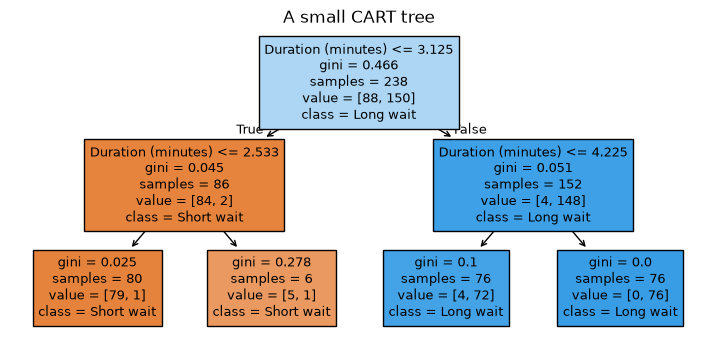

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)
tree_prediction = tree.predict(X_test)
print('CART accuracy:', round(accuracy_score(y_test, tree_prediction), 3))

plt.figure(figsize=(9, 4))
plot_tree(tree, feature_names=['Duration (minutes)'], class_names=['Short wait', 'Long wait'], filled=True, fontsize=9)
plt.title('A small CART tree')
plt.show()

## Experiment 2 · Two ensemble models
Random forest combines many trees. AdaBoost combines small models while paying more attention to earlier mistakes. Both use the same training and testing rows as CART.

,Model,Accuracy
0,CART,0.967
1,Random forest,0.967
2,AdaBoost,0.967


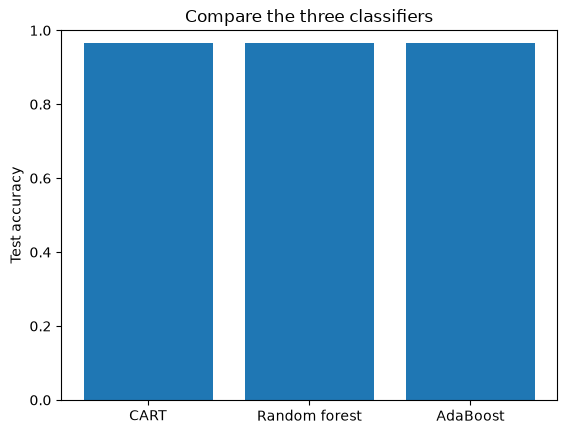

In [5]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

forest = RandomForestClassifier(n_estimators=20, max_depth=3, random_state=42)
forest.fit(X_train, y_train)
forest_prediction = forest.predict(X_test)

boost = AdaBoostClassifier(n_estimators=20, random_state=42)
boost.fit(X_train, y_train)
boost_prediction = boost.predict(X_test)

results = pd.DataFrame({
    'Model': ['CART', 'Random forest', 'AdaBoost'],
    'Accuracy': [accuracy_score(y_test, tree_prediction),
                 accuracy_score(y_test, forest_prediction),
                 accuracy_score(y_test, boost_prediction)]
})
display(results.round(3))
plt.bar(results['Model'], results['Accuracy'])
plt.ylim(0, 1)
plt.ylabel('Test accuracy')
plt.title('Compare the three classifiers')
plt.show()

## What to explain
A tree is one model; an ensemble combines several models. Compare the measured test accuracies instead of assuming more trees always win. Two ensemble methods cover the assignment without a long list of models.

**Try:** Change `n_estimators=20` to `10`.

**Viva:** What does tree depth mean? How are random forest and boosting different?